# Pointwise Scoring Network on MSLR
### Learning to Rank — Pointwise Neural Approach
---
**Dataset**: MSLR 10K   
**Model**: Pointwise Scoring Network (MLP)  
**Loss**: MSE  
**Metrics**: NDCG@K

## Project Overview

This notebook implements a **Pointwise Scoring Network** — the simplest Learning-to-Rank approach.
The network looks at **one document at a time** and directly predicts its relevance label using MSE loss.

### What this notebook covers

| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset extraction |
| 3    | Data loading via `ltr.data.load_fold` |
| 4    | Pairwise loss intuition (RankNet BCE) |
| 5    | Training and testing the Baseline model |
| 6    | Training and testing the Regularized model |
| 7    | Multiseed Evaluation for both models |
| 8    | 5-Fold Evaluation (Standard LETOR Folds) |
| 9    | Ablation study across 4 architectures |


## Step 1 · Colab Setup & Package Installation

In [1]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# This cell clones the repo (if needed) and installs the ltr package.
# Change REPO_PATH if you cloned to a different location.
import os, subprocess, sys

REPO_PATH = "/content/Learning-To-Rank-for-Search"

if not os.path.exists(REPO_PATH):
    subprocess.run(
        ["git", "clone",
         "https://github.com/navaneeswar854/Learning-To-Rank-for-Search.git",
         REPO_PATH],
        check=True,
    )
    print("Repo cloned.")
else:
    print("Repo already present.")

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", REPO_PATH + "/Pairwise Approaches", "-q"],
    check=True,
)
print("ltr package installed.")

# Add to sys.path so the kernel finds it immediately without restarting
sys.path.insert(0, REPO_PATH + "/Pairwise Approaches")


Repo cloned.
ltr package installed.


## Step 2 · Dataset Extraction

In [2]:
import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=ee06f487-efee-4cb9-9b04-a834c20bdb32
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [01:18<00:00, 18.4MB/s]


'mslr.zip'

In [3]:
# ── Extract MSLR dataset ────────────────────────────────────────────────────
import zipfile, os

ZIP_PATH  = "/content/mslr.zip"
DATA_PATH = "/content/MSLR"

if not os.path.exists(DATA_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content/")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")


Dataset extracted.


## Step 3 · Imports & Configuration

In [4]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# ── ltr package ───────────────────────────────────────────────────────────────
from ltr.data_mslr     import load_fold
from ltr.models   import ScoringMLP
from ltr.train    import train, train_multiseed, set_seed
from ltr.metrics  import mean_ndcg, per_query_ndcg, paired_significance
from ltr.evaluate import cross_fold_eval

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content"
SEEDS     = (42, 123, 456)
K_LIST    = (1, 3, 5, 10)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")


Device  : cuda
PyTorch : 2.11.0+cu128


## Step 4 · Data Loading

We use the exact 5 test splits provided by the dataset authors.

In [ ]:
train_loader, val_loader, test_loader = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

# Inspect a sample batch
sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print(f"Batch: {len(sample_qids)} queries")
print(f"Query 0 features shape: {sample_feats[0].shape}  → (num_docs, 46)")
print(f"Query 0 labels        : {sample_labels[0].tolist()}")


  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
Batch: 4 queries
Query 0 features shape: torch.Size([107, 111])  → (num_docs, 46)
Query 0 labels        : [1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 2.0, 1.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, 0.0, 2.0, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 1.0, 1.0, 0.0, 2.0, 1.0, 1.0, 2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 2.0, 2.0, 0.0, 0.0, 2.0, 0.0, 2.0, 0.0, 1.0, 0.0, 2.0, 1.0, 0.0, 2.0, 2.0, 0.0, 0.0]


## Step 5 · Training (Single Fold, Baseline Run)

Early stopping is based on **validation NDCG@10**.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(train_losses, val_ndcgs, title="Training Curves"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # 1. Find the best epoch (add 1 because epochs start at 1 in our plot)
    best_epoch = np.argmax(val_ndcgs) + 1
    best_val = val_ndcgs[best_epoch - 1]

    # 2. Draw the vertical dotted line for the best epoch
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.8,
                label=f'Best Epoch ({best_epoch})')

    # Plot Train Loss (Left Y-Axis)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Train Loss', color='tab:red')
    ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='tab:red', marker='o')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Plot Val NDCG (Right Y-Axis)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation NDCG@10', color='tab:blue')
    ax2.plot(range(1, len(val_ndcgs) + 1), val_ndcgs, label='Val NDCG@10', color='tab:blue', marker='s')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # Add legends for both axes combined
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    fig.suptitle(title)
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0).to(DEVICE)

best_model, last_model, train_loss_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="pointwise",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Train Loss: 0.8008 | Val NDCG@10: 0.4088  ← best
Epoch 02/50 | Train Loss: 0.5593 | Val NDCG@10: 0.4086
Epoch 03/50 | Train Loss: 0.5763 | Val NDCG@10: 0.4137  ← best
Epoch 04/50 | Train Loss: 0.5460 | Val NDCG@10: 0.4194  ← best
Epoch 05/50 | Train Loss: 0.5504 | Val NDCG@10: 0.4224  ← best
Epoch 06/50 | Train Loss: 0.5593 | Val NDCG@10: 0.4270  ← best
Epoch 07/50 | Train Loss: 0.5451 | Val NDCG@10: 0.4294  ← best
Epoch 08/50 | Train Loss: 0.5502 | Val NDCG@10: 0.4270
Epoch 09/50 | Train Loss: 0.5407 | Val NDCG@10: 0.4301  ← best
Epoch 10/50 | Train Loss: 0.5350 | Val NDCG@10: 0.4352  ← best
Epoch 11/50 | Train Loss: 0.5335 | Val NDCG@10: 0.4333
Epoch 12/50 | Train Loss: 0.5329 | Val NDCG@10: 0.4317
Epoch 13/50 | Train Loss: 0.5310 | Val NDCG@10: 0.4279
Epoch 14/50 | Train Loss: 0.5306 | Val NDCG@10: 0.4326
Epoch 15/50 | Train Loss: 0.5296 | Val NDCG@10: 0.4249
Epoch 16/50 | Train Loss: 0.5286 | Val NDCG@10: 0.4377  ← best
Epoch 17/50 | Train Loss: 0.5273 | Val NDCG@10: 

## Training Curve

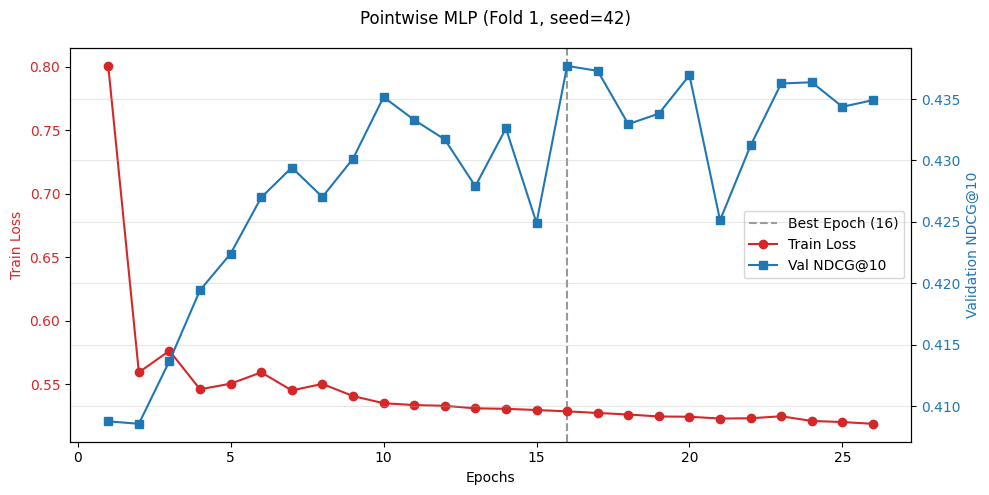

In [ ]:
plot_training_curves(train_loss_history,val_ndcg_history, "Pointwise MLP (Fold 1, seed=42)")


## Key Takeaways:

- The graph might look flattened out beacuse the initial training loss is very high(0.8).
- The difference between last Training loss and the training loss at the best val epoch is 0.0098. The trainig loss is still reducing but val NDCG didn't increase.
- Regularisation might help the model.

## Testing (single fold, single seed, baseline model)

In [ ]:
test_ndcg = mean_ndcg(best_model, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (seed=42)
──────────────────────────────
  NDCG@1  : 0.4048
  NDCG@3  : 0.4013
  NDCG@5  : 0.4075
  NDCG@10 : 0.4272


## Key Takeaways:

- The result looks better than Ranknet which is a pairwise approach which should be beat a pointwise approach.

## Next Steps:
- I will do the detailed comparison in `comparison.ipynb`
- Use regularization and see if it helps.

## Step 6: Training(single fold, single seed, Regularization(dropout=0.2))

In [ ]:
set_seed(42)
model = ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2).to(DEVICE)

best_model_reg, last_model_reg, train_loss_history, val_ndcg_history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="pointwise",
    epochs=50,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)


Epoch 01/50 | Train Loss: 0.8262 | Val NDCG@10: 0.4064  ← best
Epoch 02/50 | Train Loss: 0.5642 | Val NDCG@10: 0.4025
Epoch 03/50 | Train Loss: 0.5980 | Val NDCG@10: 0.4099  ← best
Epoch 04/50 | Train Loss: 0.5547 | Val NDCG@10: 0.4187  ← best
Epoch 05/50 | Train Loss: 0.5583 | Val NDCG@10: 0.4192  ← best
Epoch 06/50 | Train Loss: 0.5505 | Val NDCG@10: 0.4249  ← best
Epoch 07/50 | Train Loss: 0.5486 | Val NDCG@10: 0.4260  ← best
Epoch 08/50 | Train Loss: 0.5473 | Val NDCG@10: 0.4266  ← best
Epoch 09/50 | Train Loss: 0.5443 | Val NDCG@10: 0.4291  ← best
Epoch 10/50 | Train Loss: 0.5439 | Val NDCG@10: 0.4350  ← best
Epoch 11/50 | Train Loss: 0.5426 | Val NDCG@10: 0.4309
Epoch 12/50 | Train Loss: 0.5424 | Val NDCG@10: 0.4360  ← best
Epoch 13/50 | Train Loss: 0.5408 | Val NDCG@10: 0.4260
Epoch 14/50 | Train Loss: 0.5399 | Val NDCG@10: 0.4290
Epoch 15/50 | Train Loss: 0.5404 | Val NDCG@10: 0.4323
Epoch 16/50 | Train Loss: 0.5392 | Val NDCG@10: 0.4374  ← best
Epoch 17/50 | Train Loss: 0.5378

## Key Takeaways:

- The val score keeps on increasing as the training loss decreases. Therefore, Regularization is helpful.
- The val score didn't increase at last for only 3 epochs.

## Next Steps:
- Train the model for 30 more epochs.

In [ ]:
best_model_reg_cont, last_model_reg_cont, train_loss_cont, val_ndcg_cont = train(
    model=last_model_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="pointwise",
    epochs=30,
    lr=0.001,
    k=10,
    patience=10,
    device=DEVICE,
    verbose=True,
)
combined_train_loss = train_loss_history + train_loss_cont
combined_val_ndcg = val_ndcg_history + val_ndcg_cont

Epoch 01/30 | Train Loss: 0.5257 | Val NDCG@10: 0.4428  ← best
Epoch 02/30 | Train Loss: 0.5263 | Val NDCG@10: 0.4462  ← best
Epoch 03/30 | Train Loss: 0.5255 | Val NDCG@10: 0.4415
Epoch 04/30 | Train Loss: 0.5255 | Val NDCG@10: 0.4400
Epoch 05/30 | Train Loss: 0.5253 | Val NDCG@10: 0.4446
Epoch 06/30 | Train Loss: 0.5245 | Val NDCG@10: 0.4455
Epoch 07/30 | Train Loss: 0.5245 | Val NDCG@10: 0.4434
Epoch 08/30 | Train Loss: 0.5244 | Val NDCG@10: 0.4466  ← best
Epoch 09/30 | Train Loss: 0.5251 | Val NDCG@10: 0.4459
Epoch 10/30 | Train Loss: 0.5237 | Val NDCG@10: 0.4425
Epoch 11/30 | Train Loss: 0.5237 | Val NDCG@10: 0.4435
Epoch 12/30 | Train Loss: 0.5236 | Val NDCG@10: 0.4437
Epoch 13/30 | Train Loss: 0.5238 | Val NDCG@10: 0.4433
Epoch 14/30 | Train Loss: 0.5239 | Val NDCG@10: 0.4421
Epoch 15/30 | Train Loss: 0.5233 | Val NDCG@10: 0.4374
Epoch 16/30 | Train Loss: 0.5222 | Val NDCG@10: 0.4425
Epoch 17/30 | Train Loss: 0.5232 | Val NDCG@10: 0.4488  ← best
Epoch 18/30 | Train Loss: 0.5233 

## Training Curve

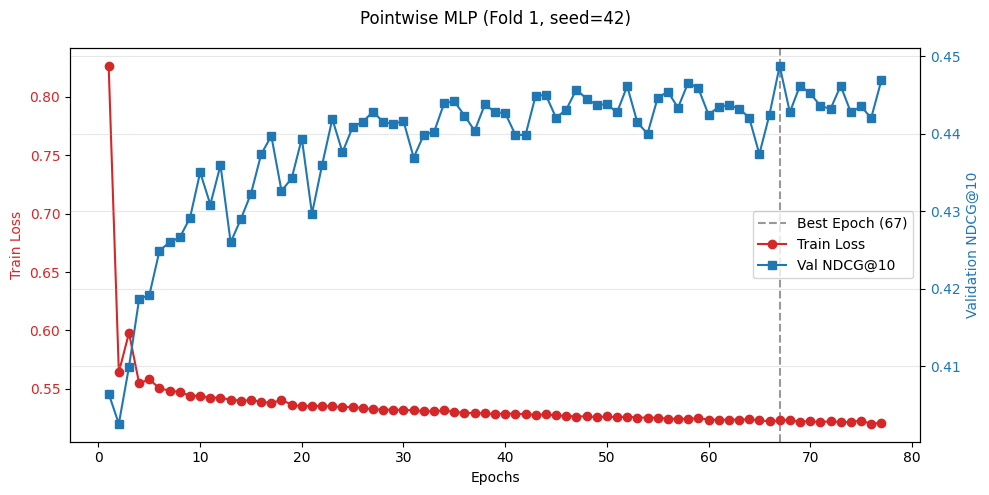

In [ ]:
plot_training_curves(combined_train_loss,combined_val_ndcg, "Pointwise MLP (Fold 1, seed=42)")

## Testing

In [ ]:
test_ndcg = mean_ndcg(best_model_reg, test_loader, k_list=K_LIST, device=DEVICE)

print("\nTest Set NDCG — Fold 1 (Best Model at Epoch=50,seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")

test_ndcg = mean_ndcg(best_model_reg_cont, test_loader, k_list=K_LIST, device=DEVICE)
print("\nTest Set NDCG — Fold 1 (Best Model at Epoch=80,seed=42)")
print(f"{'─'*30}")
for k in K_LIST:
    print(f"  NDCG@{k:<3}: {test_ndcg[k]:.4f}")



Test Set NDCG — Fold 1 (Best Model at Epoch=50,seed=42)
──────────────────────────────
  NDCG@1  : 0.4105
  NDCG@3  : 0.4033
  NDCG@5  : 0.4109
  NDCG@10 : 0.4329

Test Set NDCG — Fold 1 (Best Model at Epoch=80,seed=42)
──────────────────────────────
  NDCG@1  : 0.4062
  NDCG@3  : 0.3986
  NDCG@5  : 0.4082
  NDCG@10 : 0.4321


## Baseline Results:
NDCG@1  : 0.4048  
NDCG@3  : 0.4013  
NDCG@5  : 0.4075  
NDCG@10 : 0.4272  

## Key Takeaways:
- The Test score when we used the best model after 50 epochs is better than the test score when we used the best model after complete training. And the difference is minimal.
- This is possible. Because we are being biased on validation data while choosing the model.
- There can be some fluctuations in the score. As we can see the difference is minimal
- The difference between the scores and baseline and regularization is good. Regularization score is more but this can be because dropout choose the best sequece of networks in this seed.

## Next Step:
- Evaluate both the models with 3 different seeds and see if regularization helps most of the time.

## Step 7: Training and Testing both models with 3 different seeds

## Baseline Model

In [ ]:
pointwise_results_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.0),
    mode="pointwise",
    base_path=DATA_PATH,
    folds=[1],
    data_loader_fn=load_fold,
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4016 ± 0.0067
  NDCG@3  : 0.3969 ± 0.0042
  NDCG@5  : 0.4043 ± 0.0023
  NDCG@10 : 0.4251 ± 0.0015

═══════════════════════════════════════════════════════
  OVERALL RESULTS (POINTWISE)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4016 ± 0.0067
  NDCG@3  : 0.3969 ± 0.0042
  NDCG@5  : 0.4043 ± 0.0023
  NDCG@10 : 0.4251 ± 0.0015
═══════════════════════════════════════════════════════



#### Pointwise beats Ranknet even in multiseed

## Regularized

In [ ]:
pointwise_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2),
    mode="pointwise",
    base_path=DATA_PATH,
    folds=[1],
    data_loader_fn=load_fold,
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4086 ± 0.0037
  NDCG@3  : 0.4018 ± 0.0027
  NDCG@5  : 0.4098 ± 0.0015
  NDCG@10 : 0.4310 ± 0.0017

═══════════════════════════════════════════════════════
  OVERALL RESULTS (POINTWISE)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4086 ± 0.0037
  NDCG@3  : 0.4018 ± 0.0027
  NDCG@5  : 0.4098 ± 0.0015
  NDCG@10 : 0.4310 ± 0.0017
═══════════════════════════════════════════════════════



## Results:

| Metric | Baseline | Regularized(0.2) |   
| ------ | -------- | ---------------- |
| NDCG@1 | 0.402 ± 0.007 | 0.409 ± 0.004 |   
| NDCG@3 | 0.397 ± 0.004 | 0.402 ± 0.003 |   
| NDCG@5 | 0.404 ± 0.002 | 0.410 ± 0.002 |   
| NDCG@10 | 0.425 ± 0.002 | 0.431 ± 0.002 |

## Key Takeaways:

- So, The Regularization helped the model and we got better results than the baseline model.
- The variance is very low. Therefore, we can get the similar result most of the time.
- So, we can conclude that Regularized performs better than Baseline.

## Next Step:

- Perform a 5-fold cross validation and check if the Data split is good enough.

## Step 8 · 5-Fold Evaluation (Standard MSLR Folds)

We are using the exact 5 test splits provided by the dataset authors, rather than
shuffling and making our own cross-validation splits. This makes sure our results
can be fairly compared to published papers.


In [5]:
def print_results_table(results, title, k_list=(1, 3, 5, 10)):
    """Pretty-print a cross_fold_eval or train_multiseed results dict."""
    summary = results.get("overall", results.get("summary", {}))
    print(f"\n{'═'*45}")
    print(f"  {title}")
    print(f"{'═'*45}")
    print(f"{'Metric':<10}  {'Mean':>8}  {'Std':>8}")
    print(f"{'─'*45}")
    for k in k_list:
        if k in summary:
            m, s = summary[k]["mean"], summary[k]["std"]
            print(f"NDCG@{k:<5}  {m:>8.4f}  {s:>8.4f}")
    print(f"{'═'*45}")


In [12]:
pointwise_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64], dropout=0.2),
    mode="pointwise",
    base_path=DATA_PATH,
    folds=(1, 2, 3, 4, 5),
    data_loader_fn=load_fold,
    seeds=[42],
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)

print_results_table(pointwise_results, "POINTWISE — 5-Fold Results")



═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4105 ± 0.0000
  NDCG@3  : 0.4033 ± 0.0000
  NDCG@5  : 0.4109 ± 0.0000
  NDCG@10 : 0.4329 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════
  [Fold 2] Loading train split and computing normalization stats...


  [Fold 2] Loading val split (using train stats)...


...

  [Fold 4] Loading test split (using train stats)...


  Fold 4: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4147 ± 0.0000
  NDCG@3  : 0.4086 ± 0.0000
  NDCG@5  : 0.4153 ± 0.0000
  NDCG@10 : 0.4374 ± 0.0000

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════
  [Fold 5] Loading train split and computing normalization stats...


  [Fold 5] Loading val split (using train stats)...


  [Fold 5] Loading test split (using train stats)...


  Fold 5: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4230 ± 0.0000
  NDCG@3  : 0.4158 ± 0.0000
  NDCG@5  : 0.4234 ± 0.0000
  NDCG@10 : 0.4441 ± 0.0000

═══════════════════════════════════════════════════════
  OVERALL RESULTS (POINTWISE)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4110 ± 0.0074
  NDCG@3  : 0.4044 ± 0.0072
  NDCG@5  : 0.4111 ± 0.0077
  NDCG@10 : 0.4333 ± 0.0071
═══════════════════════════════════════════════════════


═════════════════════════════════════════════
  POINTWISE — 5-Fold Results
═════════════════════════════════════════════
Metric          Mean       Std
─────────────────────────────────────────────
NDCG@1        0.4110    0.0074
NDCG@3        0.4044    0.0072
NDCG@5        0.4111    0.0077
NDCG@10       0.4333    0.0071
═════════════════════════════════════════════


## Key Takeaways:

- The variance across different folds is low. The model's performance is stable.

## Next Steps:
- Perform an ablation study to see how the results vary with depth.
- To perform ablation study i am using the fold which gave closer result to the mean score(Fold).

## Save Results

Results are saved as JSON for use in `04_comparison.ipynb`.

In [7]:
import json

os.makedirs("/content/ltr_results", exist_ok=True)

# Convert numpy floats to native Python floats for JSON serialisation
def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    return obj

with open("/content/ltr_results/pointwise_results.json", "w") as f:
    json.dump(to_serialisable(pointwise_results), f, indent=2)

print("Results saved to /content/ltr_results/pointwise_results.json")


Results saved to /content/ltr_results/pointwise_results.json


## Step 9 · Ablation Study — Architecture Comparison

We lock the data to **Fold 1** and swap out the underlying network architecture,
keeping everything else identical. This isolates the impact of depth and
dropout regularization on NDCG@10.

| Config | Hidden dims | Dropout |
|---|---|---|
| Linear | `[]` | 0.0 |
| Shallow | `[64, 32]` | 0.0 |
| Deep | `[128, 64, 32]` | 0.2 |

In [8]:
# ── Lock data to Fold 1 ───────────────────────────────────────────────────────
train_loader_f1, val_loader_f1, test_loader_f1 = load_fold(
    base_path=DATA_PATH, fold_num=1, batch_size=4
)

# ── Ablation configurations ───────────────────────────────────────────────────
ablation_configs = {
    "Linear":      {"hidden_dims": [],              "dropout": 0.0},
    "Shallow": {"hidden_dims": [64, 32],         "dropout": 0.0},
    "Deep":        {"hidden_dims": [128, 64, 32],"dropout": 0.2},
}

ablation_results = {}

for arch_name, cfg in ablation_configs.items():
    print(f"\nTraining {arch_name} ...")
    result = train_multiseed(
        model_fn=lambda h=cfg["hidden_dims"], d=cfg["dropout"]: ScoringMLP(111, h, d),
        train_loader=train_loader_f1,
        val_loader=val_loader_f1,
        test_loader=test_loader_f1,
        mode="pointwise",
        seeds=[42],
        k_list=K_LIST,
        device=DEVICE,
        epochs=50,
        patience=10,
        verbose=False,
    )
    ablation_results[arch_name] = result["summary"]
    ndcg10 = result["summary"][10]
    print(f"  NDCG@10: {ndcg10['mean']:.4f} ± {ndcg10['std']:.4f}")


  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))

Training Linear ...
  NDCG@10: 0.3659 ± 0.0000

Training Shallow ...
  NDCG@10: 0.4266 ± 0.0000

Training Deep ...
  NDCG@10: 0.4346 ± 0.0000


In [10]:
# ── Ablation results table ────────────────────────────────────────────────────
print(f"\n{'═'*50}")
print(f"  ABLATION STUDY — NDCG@10 (Fold 1)")
print(f"{'═'*50}")
print(f"{'Architecture':<15}  {'NDCG@1':>5}  {'NDCG@3':>5}  {'NDCG@5':>5}  {'NDCG@10':>5}")
print(f"{'─'*50}")
for arch_name, summary in ablation_results.items():
    row = "  ".join(
        f"{summary[k]['mean']:>6.4f}" for k in [1, 3, 5, 10]
    )
    print(f"{arch_name:<15}  {row}")
print(f"{'═'*50}")



══════════════════════════════════════════════════
  ABLATION STUDY — NDCG@10 (Fold 1)
══════════════════════════════════════════════════
Architecture     NDCG@1  NDCG@3  NDCG@5  NDCG@10
──────────────────────────────────────────────────
Linear           0.3065  0.3272  0.3381  0.3659
Shallow          0.4117  0.4004  0.4049  0.4266
Deep             0.4165  0.4088  0.4148  0.4346
══════════════════════════════════════════════════


**Baseline**   
NDCG@1       - 0.4110    
NDCG@3       - 0.4044    
NDCG@5       - 0.4111     
NDCG@10- 0.4333
## Key Takeaways:

- As expected, a shallow model under performed.
- But the deep model outperformed the Baseline model. So, Increasing the depth is useful in this case.
- Linear(Logistic Regression) performed the worst among them with major difference in NDCG score proving that ranking pattern is not linear.

## Next Step:
- Perform a multiseed evaluation on Deep model with same seed and fold and compare with the base line model.

In [11]:
pointwise_results = cross_fold_eval(
    model_fn=lambda: ScoringMLP(input_dim=111, hidden_dims=[128, 64, 32], dropout=0.2),
    mode="pointwise",
    base_path=DATA_PATH,
    folds=[1],
    data_loader_fn=load_fold,
    seeds=SEEDS,
    k_list=K_LIST,
    batch_size=4,
    device=DEVICE,
    epochs=50,
    patience=10,
)


═══════════════════════════════════════════════════════
  FOLD 1 / 1
═══════════════════════════════════════════════════════
  [Fold 1] Loading train split and computing normalization stats...


  [Fold 1] Loading val split (using train stats)...


  [Fold 1] Loading test split (using train stats)...


  Fold 1: 6000 train | 2000 val | 2000 test queries
  Features: 111 (136 total − 25 dropped)
  Normalization: global z-score fit on train (mean/std shapes: (111,))
  NDCG@1  : 0.4130 ± 0.0030
  NDCG@3  : 0.4064 ± 0.0019
  NDCG@5  : 0.4124 ± 0.0018
  NDCG@10 : 0.4325 ± 0.0018

═══════════════════════════════════════════════════════
  OVERALL RESULTS (POINTWISE)
═══════════════════════════════════════════════════════
  NDCG@1  : 0.4130 ± 0.0030
  NDCG@3  : 0.4064 ± 0.0019
  NDCG@5  : 0.4124 ± 0.0018
  NDCG@10 : 0.4325 ± 0.0018
═══════════════════════════════════════════════════════



**Baseline(Regularized, Multiseed)**   
NDCG@1       - 0.409 ± 0.004    
NDCG@3       - 0.402 ± 0.003    
NDCG@5       - 0.410 ± 0.002     
NDCG@10- 0.431 ± 0.002

## Key Takeaways:
- The Deep model is better than Baseline especially at the top. But the difference is small.
- The higher NDCG we got in Ablation study is probably because of the randomness.
- Increasing depth will give almost same result with more parameters and taking more time for training. Therefore, We can prefer baseline model over the Deep model.

## Conclusion

- Pointwise performed better than Pairwise approach
- Regularization helped the network in this case
- Deep model is as good as baseline model but the gain in score is not good enough to choose it over baseline model.